# Molecule Analysis Data Audit

This notebook profiles the datasets in `data/` and produces a compact inventory for planning math, machine learning, and graph-based work.

Goals:
- inventory every dataset file
- classify likely task type
- measure missingness and identifier quality
- surface first-wave datasets for implementation

In [5]:
import csv
import os
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path(os.environ.get("DATA_DIR"))
print(f"Data dir: {DATA_DIR}")

Data dir: /opt/molecule-analysis/data


## Audit Helpers

In [10]:
@dataclass
class DatasetSummary:
    file_name: str
    suffix: str
    size_kb: float
    row_count: int | None
    column_count: int | None
    task_type: str
    target_columns: list[str]
    candidate_keys: list[str]
    best_key: str | None
    best_key_unique: bool | None
    missing_cells: int | None
    missing_rate: float | None
    notes: str


def infer_target_columns(file_name: str, columns: list[str]) -> list[str]:
    lower_name = file_name.lower()
    if lower_name == "bbbp.csv":
        return ["p_np"]
    if lower_name == "clintox.csv":
        return ["FDA_APPROVED", "CT_TOX"]
    if lower_name == "hiv.csv":
        return ["activity", "HIV_active"]
    if lower_name == "lipophilicity.csv":
        return ["exp"]
    if lower_name == "sampl.csv":
        return ["expt", "calc"]
    if lower_name == "delaney-processed.csv":
        return ["measured log solubility in mols per litre"]
    if lower_name == "bace.csv":
        return ["Class", "pIC50"]
    if lower_name == "tox21.csv":
        return columns[:12]
    if lower_name == "sider.csv":
        return columns[1:]
    if lower_name == "muv.csv":
        return columns[:-2]
    if lower_name == "toxcast_data.csv":
        return [col for col in columns if col != "smiles"]
    if lower_name == "qm8.csv":
        return [col for col in columns if col != "smiles"]
    if lower_name == "qm9.csv":
        return [col for col in columns if col not in {"mol_id", "smiles"}]
    return []


def candidate_key_columns(columns: list[str]) -> list[str]:
    priority_terms = ("id", "smiles", "name", "iupac", "cid", "chembl")
    matches = []
    for col in columns:
        low = col.lower()
        if any(term in low for term in priority_terms):
            matches.append(col)
    return matches


def key_profile(
    rows: list[dict[str, str]], columns: list[str]
) -> tuple[list[str], str | None, bool | None]:
    candidates = candidate_key_columns(columns)
    best_key = None
    best_key_unique = None

    for col in candidates:
        values = [row[col].strip() for row in rows]
        nonempty = [value for value in values if value != ""]
        if len(nonempty) != len(rows):
            continue
        is_unique = len(set(nonempty)) == len(nonempty)
        if is_unique:
            best_key = col
            best_key_unique = True
            if col.lower() in {
                "mol_id",
                "cid",
                "cmpd_chemblid",
                "compound id",
                "num",
                "smiles",
            }:
                break
        if best_key is None:
            best_key = col
            best_key_unique = False

    return candidates, best_key, best_key_unique


def summarize_csv(path: Path) -> DatasetSummary:
    with path.open(newline="") as handle:
        rows = list(csv.DictReader(handle))
        columns = rows[0].keys() if rows else []

    column_list = list(columns)
    total_cells = len(rows) * len(column_list) if rows else 0
    missing_cells = sum(
        1 for row in rows for value in row.values() if value.strip() == ""
    )
    missing_rate = (missing_cells / total_cells) if total_cells else None
    candidates, best_key, best_key_unique = key_profile(rows, column_list)

    notes = []
    duplicate_headers = [
        col for col, count in Counter(column_list).items() if count > 1
    ]
    if duplicate_headers:
        notes.append(f"duplicate headers: {duplicate_headers}")
    if path.name == "toxcast_data.csv":
        notes.append("wide sparse multitask assay matrix")
    if path.name == "qm8.csv":
        notes.append("duplicate PBE0 headers need normalization before modeling")
    if path.name == "qm9.csv":
        notes.append("multi-target quantum regression with clean mol_id")

    return DatasetSummary(
        file_name=path.name,
        suffix=path.suffix,
        size_kb=round(path.stat().st_size / 1024, 2),
        row_count=len(rows),
        column_count=len(column_list),
        target_columns=infer_target_columns(path.name, column_list),
        candidate_keys=candidates,
        best_key=best_key,
        best_key_unique=best_key_unique,
        missing_cells=missing_cells,
        missing_rate=missing_rate,
        notes="; ".join(notes),
    )


def summarize_mat(path: Path) -> DatasetSummary:
    return DatasetSummary(
        file_name=path.name,
        suffix=path.suffix,
        size_kb=round(path.stat().st_size / 1024, 2),
        row_count=None,
        column_count=None,
        task_type="quantum-regression-mat",
        target_columns=[],
        candidate_keys=[],
        best_key=None,
        best_key_unique=None,
        missing_cells=None,
        missing_rate=None,
        notes="MATLAB binary file; inspect later with scipy.io.loadmat or h5py if needed",
    )

In [14]:
summaries: list[DatasetSummary] = []
for path in sorted(DATA_DIR.iterdir()):
    if path.suffix.lower() == ".csv":
        summaries.append(summarize_csv(path))
    elif path.suffix.lower() == ".mat":
        summaries.append(summarize_mat(path))

summary_df = pd.DataFrame([summary.__dict__ for summary in summaries])
summary_df["missing_rate"] = summary_df["missing_rate"].round(4)
summary_df = summary_df.sort_values(["task_type", "file_name"]).reset_index(drop=True)
display(summary_df)

,file_name,suffix,size_kb,row_count,column_count,task_type,target_columns,candidate_keys,best_key,best_key_unique,missing_cells,missing_rate,notes
0,BBBP.csv,.csv,145.26,2050.0,4.0,binary-classification,[p_np],"[name, smiles]",smiles,True,0.0,0.0000,
1,HIV.csv,.csv,2142.43,41127.0,3.0,binary-classification,"[activity, HIV_active]",[smiles],smiles,True,0.0,0.0000,
2,clintox.csv,.csv,93.27,1484.0,3.0,binary-classification,"[FDA_APPROVED, CT_TOX]",[smiles],smiles,True,0.0,0.0000,
3,qm8.csv,.csv,4608.66,21786.0,13.0,multi-target-regression,"[E1-CC2, E2-CC2, f1-CC2, f2-CC2, E1-PBE0, E2-PBE0, f1-PBE0, f2-PBE0, E1-CAM, E2-CAM, f1-CAM, f2-CAM]",[smiles],smiles,False,0.0,0.0000,duplicate PBE0 headers need normalization before modeling
4,qm9.csv,.csv,29157.06,133885.0,21.0,multi-target-regression,"[A, B, C, mu, alpha, homo, lumo, gap, r2, zpve, u0, u298, h298, g298, cv, u0_atom, u298_atom, h298_atom, g298_atom]","[mol_id, smiles]",mol_id,True,0.0,0.0000,multi-target quantum regression with clean mol_id
5,muv.csv,.csv,6659.70,93087.0,19.0,multitask-classification,"[MUV-466, MUV-548, MUV-600, MUV-644, MUV-652, MUV-689, MUV-692, MUV-712, MUV-713, MUV-733, MUV-737, MUV-810, MUV-832...","[mol_id, smiles]",mol_id,True,1332593.0,0.7535,
6,sider.csv,.csv,179.44,1427.0,28.0,multitask-classification,"[Hepatobiliary disorders, Metabolism and nutrition disorders, Product issues, Eye disorders, Investigations, Musculo...",[smiles],smiles,True,0.0,0.0000,
7,tox21.csv,.csv,512.81,7831.0,14.0,multitask-classification,"[NR-AR, NR-AR-LBD, NR-AhR, NR-Aromatase, NR-ER, NR-ER-LBD, NR-PPAR-gamma, SR-ARE, SR-ATAD5, SR-HSE, SR-MMP, SR-p53]","[mol_id, smiles]",mol_id,True,16026.0,0.1462,
8,toxcast_data.csv,.csv,10040.29,8597.0,618.0,multitask-classification,"[ACEA_T47D_80hr_Negative, ACEA_T47D_80hr_Positive, APR_HepG2_CellCycleArrest_24h_dn, APR_HepG2_CellCycleArrest_24h_u...","[smiles, APR_HepG2_OxidativeStress_24h_up, APR_HepG2_OxidativeStress_72h_up]",smiles,False,3765954.0,0.7088,wide sparse multitask assay matrix
9,qm7b.mat,.mat,15690.52,NaN,NaN,quantum-regression-mat,[],[],NaN,None,NaN,NaN,MATLAB binary file; inspect later with scipy.io.loadmat or h5py if needed


## First-Wave Recommendations

In [15]:
tier_a = {
    "BBBP.csv",
    "clintox.csv",
    "delaney-processed.csv",
    "Lipophilicity.csv",
    "SAMPL.csv",
}
tier_b = {"HIV.csv", "tox21.csv", "sider.csv", "muv.csv"}
tier_c = {"toxcast_data.csv", "qm8.csv", "qm9.csv", "qm7b.mat", "bace.csv"}


def assign_tier(file_name: str) -> str:
    if file_name in tier_a:
        return "A"
    if file_name in tier_b:
        return "B"
    if file_name in tier_c:
        return "C"
    return "review"


summary_df["tier"] = summary_df["file_name"].map(assign_tier)
display(
    summary_df[
        [
            "file_name",
            "tier",
            "task_type",
            "row_count",
            "column_count",
            "best_key",
            "best_key_unique",
            "missing_rate",
            "notes",
        ]
    ]
)

,file_name,tier,task_type,row_count,column_count,best_key,best_key_unique,missing_rate,notes
0,BBBP.csv,A,binary-classification,2050.0,4.0,smiles,True,0.0000,
1,HIV.csv,B,binary-classification,41127.0,3.0,smiles,True,0.0000,
2,clintox.csv,A,binary-classification,1484.0,3.0,smiles,True,0.0000,
3,qm8.csv,C,multi-target-regression,21786.0,13.0,smiles,False,0.0000,duplicate PBE0 headers need normalization before modeling
4,qm9.csv,C,multi-target-regression,133885.0,21.0,mol_id,True,0.0000,multi-target quantum regression with clean mol_id
5,muv.csv,B,multitask-classification,93087.0,19.0,mol_id,True,0.7535,
6,sider.csv,B,multitask-classification,1427.0,28.0,smiles,True,0.0000,
7,tox21.csv,B,multitask-classification,7831.0,14.0,mol_id,True,0.1462,
8,toxcast_data.csv,C,multitask-classification,8597.0,618.0,smiles,False,0.7088,wide sparse multitask assay matrix
9,qm7b.mat,C,quantum-regression-mat,NaN,NaN,NaN,None,NaN,MATLAB binary file; inspect later with scipy.io.loadmat or h5py if needed


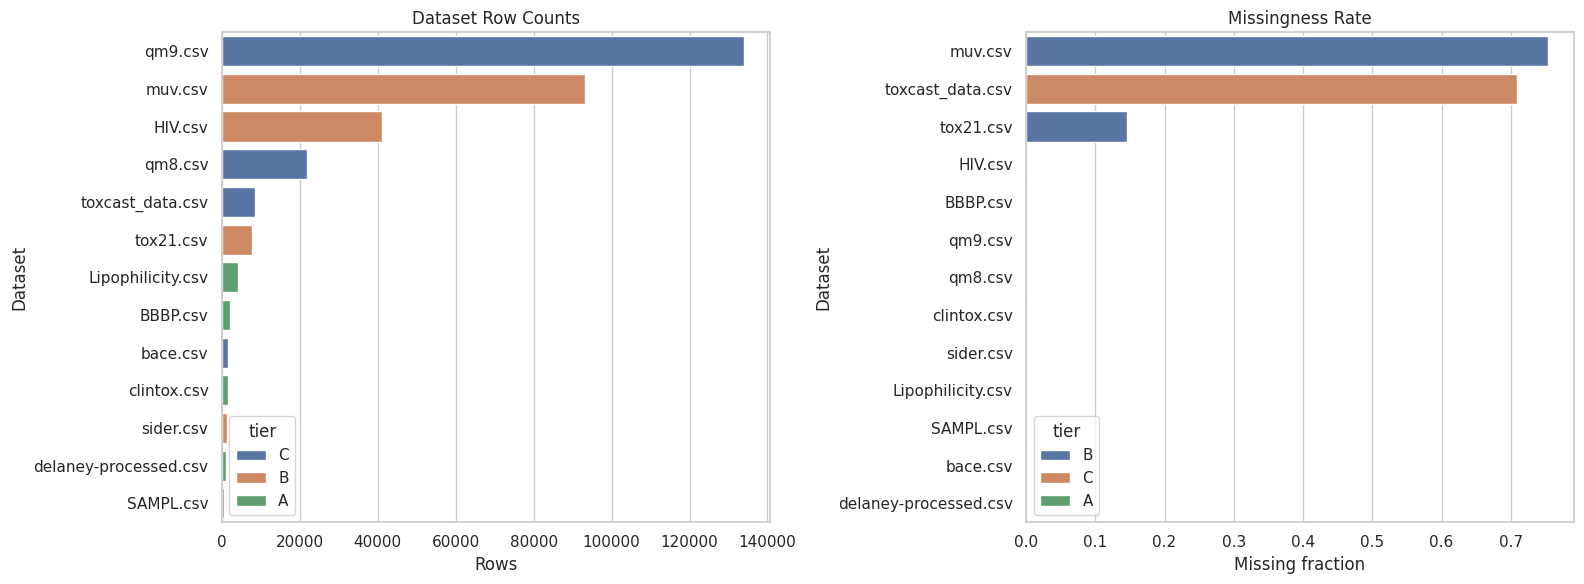

In [16]:
plot_df = summary_df.dropna(subset=["row_count", "column_count"]).copy()
plot_df["shape_label"] = (
    plot_df["row_count"].astype(int).astype(str)
    + " x "
    + plot_df["column_count"].astype(int).astype(str)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=plot_df.sort_values("row_count", ascending=False),
    x="row_count",
    y="file_name",
    hue="tier",
    ax=axes[0],
)
axes[0].set_title("Dataset Row Counts")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("Dataset")

sns.barplot(
    data=plot_df.sort_values("missing_rate", ascending=False),
    x="missing_rate",
    y="file_name",
    hue="tier",
    ax=axes[1],
)
axes[1].set_title("Missingness Rate")
axes[1].set_xlabel("Missing fraction")
axes[1].set_ylabel("Dataset")

plt.tight_layout()
plt.show()

## Deep Dive: Identifier Quality

In [17]:
def inspect_identifier_quality(path: Path) -> pd.DataFrame:
    rows = list(csv.DictReader(path.open(newline="")))
    columns = list(rows[0].keys())
    candidates = candidate_key_columns(columns)
    records = []
    for col in candidates:
        values = [row[col].strip() for row in rows]
        nonempty = [v for v in values if v]
        unique_count = len(set(nonempty))
        records.append(
            {
                "column": col,
                "nonempty": len(nonempty),
                "unique": unique_count,
                "duplicate_values": sum(
                    1 for _, count in Counter(nonempty).items() if count > 1
                ),
                "is_complete": len(nonempty) == len(rows),
                "is_unique": unique_count == len(nonempty),
            }
        )
    return pd.DataFrame(records).sort_values(
        ["is_unique", "is_complete", "column"], ascending=[False, False, True]
    )


for file_name in [
    "BBBP.csv",
    "clintox.csv",
    "delaney-processed.csv",
    "Lipophilicity.csv",
    "SAMPL.csv",
    "tox21.csv",
    "toxcast_data.csv",
    "qm8.csv",
    "qm9.csv",
]:
    path = DATA_DIR / file_name
    print(f"\n### {file_name}")
    display(inspect_identifier_quality(path))


### BBBP.csv


,column,nonempty,unique,duplicate_values,is_complete,is_unique
1,smiles,2050,2050,0,True,True
0,name,2050,2022,28,True,False



### clintox.csv


,column,nonempty,unique,duplicate_values,is_complete,is_unique
0,smiles,1484,1484,0,True,True



### delaney-processed.csv


...

,column,nonempty,unique,duplicate_values,is_complete,is_unique
0,smiles,8597,8583,1,True,False
1,APR_HepG2_OxidativeStress_24h_up,1039,2,2,False,False
2,APR_HepG2_OxidativeStress_72h_up,1039,2,2,False,False



### qm8.csv


,column,nonempty,unique,duplicate_values,is_complete,is_unique
0,smiles,21786,21766,20,True,False



### qm9.csv


,column,nonempty,unique,duplicate_values,is_complete,is_unique
0,mol_id,133885,133885,0,True,True
1,smiles,133885,133802,83,True,False


## Actionable Output

Use this table as the contract for the next notebooks: which dataset to start with, which identifier to trust, and whether target columns need missing-label handling.

In [18]:
starter_plan = summary_df.loc[
    summary_df["tier"] == "A",
    [
        "file_name",
        "task_type",
        "target_columns",
        "best_key",
        "best_key_unique",
        "missing_rate",
        "notes",
    ],
].copy()
starter_plan["recommended_role"] = [
    "binary classification baseline"
    if task == "binary-classification"
    else "regression baseline"
    for task in starter_plan["task_type"]
]
display(starter_plan.sort_values(["task_type", "file_name"]))

,file_name,task_type,target_columns,best_key,best_key_unique,missing_rate,notes,recommended_role
0,BBBP.csv,binary-classification,[p_np],smiles,True,0.0,,binary classification baseline
2,clintox.csv,binary-classification,"[FDA_APPROVED, CT_TOX]",smiles,True,0.0,,binary classification baseline
10,Lipophilicity.csv,regression,[exp],CMPD_CHEMBLID,True,0.0,,regression baseline
11,SAMPL.csv,regression,"[expt, calc]",smiles,True,0.0,,regression baseline
13,delaney-processed.csv,regression,[measured log solubility in mols per litre],Compound ID,True,0.0,,regression baseline
